# 🌍 Hybrid AQI Prediction Model: SARIMA + XGBoost + SHAP
---
## Architecture
```
[Raw Data] → [Preprocessing] → [SARIMA] → [Feature Fusion] → [XGBoost] → [SHAP] → [Final Prediction + Explanation]
```

**Pipeline Overview:**
1. **Data Preprocessing** — Handle missing values, normalize, create lag & rolling features, set time index
2. **SARIMA** — Capture temporal seasonality in AQI time series
3. **Feature Fusion** — Combine SARIMA predictions with pollutant, weather & engineered features
4. **XGBoost** — Model nonlinear relationships on enriched feature set
5. **SHAP (XAI)** — Explain feature contributions globally and locally
6. **Evaluation** — Compare SARIMA vs XGBoost vs Hybrid using MAE, RMSE, MAPE

## 0. Install Dependencies
Run this cell once to install all required packages into the current Jupyter kernel.

In [8]:
import subprocess, sys
packages = ['statsmodels', 'xgboost', 'shap', 'seaborn', 'scikit-learn']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('All dependencies installed successfully.')

All dependencies installed successfully.


## 1. Imports & Configuration

In [9]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import xgboost as xgb
import shap

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Data Loading & Initial Exploration

In [10]:
df_raw = pd.read_csv('../aqi_era5_daily_2015_2019_clean.csv', parse_dates=['date'])
print(f'Dataset shape: {df_raw.shape}')
print(f'Date range: {df_raw.date.min()} to {df_raw.date.max()}')
print(f'Cities: {df_raw.city.unique()}')
df_raw.head()

Dataset shape: (5836, 19)
Date range: 2015-01-01 00:00:00 to 2019-12-31 00:00:00
Cities: ['Bengaluru' 'Chennai' 'Delhi' 'Mumbai']


,date,city,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket,t2m,d2m,sp,blh,u10,v10
0,2015-03-21,Bengaluru,48.59,NaN,3.47,27.00,18.04,28.02,3.89,1.94,52.96,91.0,Satisfactory,300.303338,281.864541,91777.695250,1044.855022,-2.822911,1.153917
1,2015-03-22,Bengaluru,47.38,NaN,2.84,22.39,15.33,23.19,11.29,2.05,71.85,120.0,Moderate,301.190204,283.052098,91669.398448,1112.918207,-2.347903,0.964298
2,2015-03-23,Bengaluru,65.65,NaN,3.10,26.35,17.45,27.76,9.95,6.30,72.84,154.0,Moderate,301.723871,286.684789,91544.727823,1129.425099,-1.327358,0.442599
3,2015-03-24,Bengaluru,60.47,NaN,5.39,29.87,20.88,35.10,1.46,6.07,64.12,119.0,Moderate,301.569298,286.892019,91458.611854,1257.101676,-2.269228,0.585144
4,2015-03-25,Bengaluru,62.56,NaN,3.16,23.57,16.39,27.13,10.05,4.98,82.34,232.0,Poor,300.979277,286.872962,91557.372344,1295.268403,-3.036907,1.409642


In [11]:
print('--- Column Info ---')
print(df_raw.dtypes)
print('\n--- Missing Values ---')
missing = df_raw.isnull().sum()
print(missing[missing > 0])
print(f'\n--- AQI Stats ---')
df_raw['AQI'].describe()

--- Column Info ---
date          datetime64[ns]
city                  object
PM2.5                float64
PM10                 float64
NO                   float64
NO2                  float64
NOx                  float64
NH3                  float64
CO                   float64
SO2                  float64
O3                   float64
AQI                  float64
AQI_Bucket            object
t2m                  float64
d2m                  float64
sp                   float64
blh                  float64
u10                  float64
v10                  float64
dtype: object

--- Missing Values ---
PM2.5      14
PM10     1822
NO         39
NO2        17
NOx        17
NH3       886
CO         18
SO2        88
O3        124
dtype: int64

--- AQI Stats ---


count    5836.000000
mean      156.744688
std       107.476156
min        20.000000
25%        81.000000
50%       115.000000
75%       198.000000
max       716.000000
Name: AQI, dtype: float64

Modeling city: Bengaluru | Records: 1727 | Range: 2015-03-21 00:00:00 to 2019-12-31 00:00:00


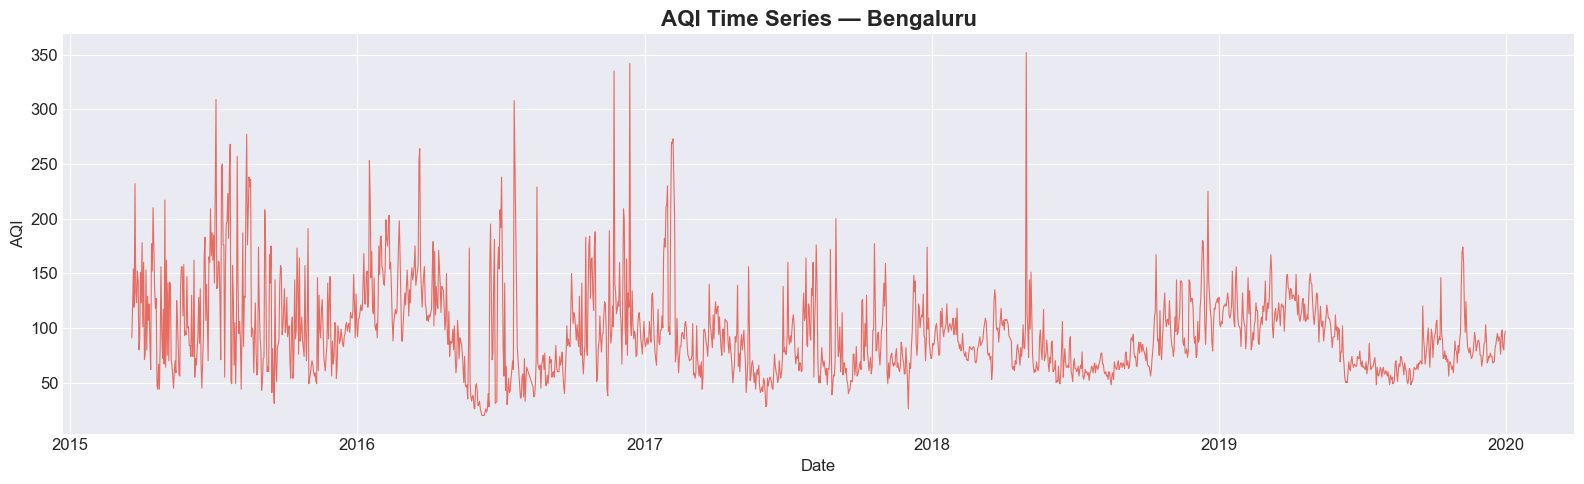

In [12]:
# Select a single city for focused modeling (Bengaluru has the most data from 2015)
CITY = 'Bengaluru'
df = df_raw[df_raw['city'] == CITY].copy().sort_values('date').reset_index(drop=True)
df.set_index('date', inplace=True)
print(f'Modeling city: {CITY} | Records: {len(df)} | Range: {df.index.min()} to {df.index.max()}')

# Plot AQI time series
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df['AQI'], color='#e74c3c', linewidth=0.8, alpha=0.8)
ax.set_title(f'AQI Time Series — {CITY}', fontsize=16, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('AQI')
plt.tight_layout(); plt.show()

## 3. Data Preprocessing

In [13]:
# Define feature groups
POLLUTANTS = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3']
WEATHER = ['t2m', 'd2m', 'sp', 'blh', 'u10', 'v10']  # ERA5 variables
TARGET = 'AQI'

# Keep only relevant columns
keep_cols = POLLUTANTS + WEATHER + [TARGET]
df = df[[c for c in keep_cols if c in df.columns]].copy()

# 3a. Handle missing values: forward-fill then backward-fill, then drop remaining
print(f'Missing BEFORE: {df.isnull().sum().sum()}')
df = df.ffill().bfill()
df.dropna(inplace=True)
print(f'Missing AFTER : {df.isnull().sum().sum()}')
print(f'Final records : {len(df)}')

Missing BEFORE: 449
Missing AFTER : 0
Final records : 1727


In [14]:
# 3b. Resample to regular daily frequency (fill gaps)
df = df.asfreq('D')
df = df.ffill().bfill()
print(f'Regular daily index — {len(df)} days, freq={df.index.freq}')

Regular daily index — 1747 days, freq=<Day>


In [15]:
# 3c. Create lag features for AQI
for lag in [1, 2, 3, 7, 14]:
    df[f'AQI_lag_{lag}'] = df[TARGET].shift(lag)

# 3d. Rolling statistics
df['AQI_roll_7_mean'] = df[TARGET].shift(1).rolling(window=7).mean()
df['AQI_roll_7_std']  = df[TARGET].shift(1).rolling(window=7).std()
df['AQI_roll_30_mean'] = df[TARGET].shift(1).rolling(window=30).mean()

# 3e. Time-based features
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['day_of_year'] = df.index.dayofyear
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)

# Drop rows with NaN from lag/rolling
df.dropna(inplace=True)
print(f'After feature engineering: {df.shape}')
df.head()

After feature engineering: (1717, 28)


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,t2m,...,AQI_lag_3,AQI_lag_7,AQI_lag_14,AQI_roll_7_mean,AQI_roll_7_std,AQI_roll_30_mean,day_of_week,month,day_of_year,is_weekend
date,,,,,,,,,,,,,,,,,,,,,
2015-04-20,27.46,70.46,2.53,7.91,7.10,24.78,4.58,5.53,37.22,299.973845,...,210.0,85.0,71.0,141.571429,52.328632,129.266667,0,4,110,0
2015-04-21,27.94,70.46,3.80,6.45,9.94,17.34,6.14,4.43,34.74,299.917153,...,170.0,62.0,76.0,146.285714,47.661005,130.166667,1,4,111,0
2015-04-22,23.81,70.46,4.01,6.21,13.57,5.42,6.14,26.42,32.79,300.029123,...,135.0,177.0,153.0,155.571429,32.387534,130.400000,2,4,112,0
2015-04-23,23.11,70.46,4.16,6.84,14.07,18.77,3.65,12.35,15.88,298.323166,...,118.0,152.0,80.0,137.000000,50.345473,126.833333,3,4,113,0
2015-04-24,15.12,70.46,4.35,14.96,12.52,35.77,1.13,5.12,109.66,298.567908,...,127.0,210.0,129.0,121.571429,60.505805,124.333333,4,4,114,0


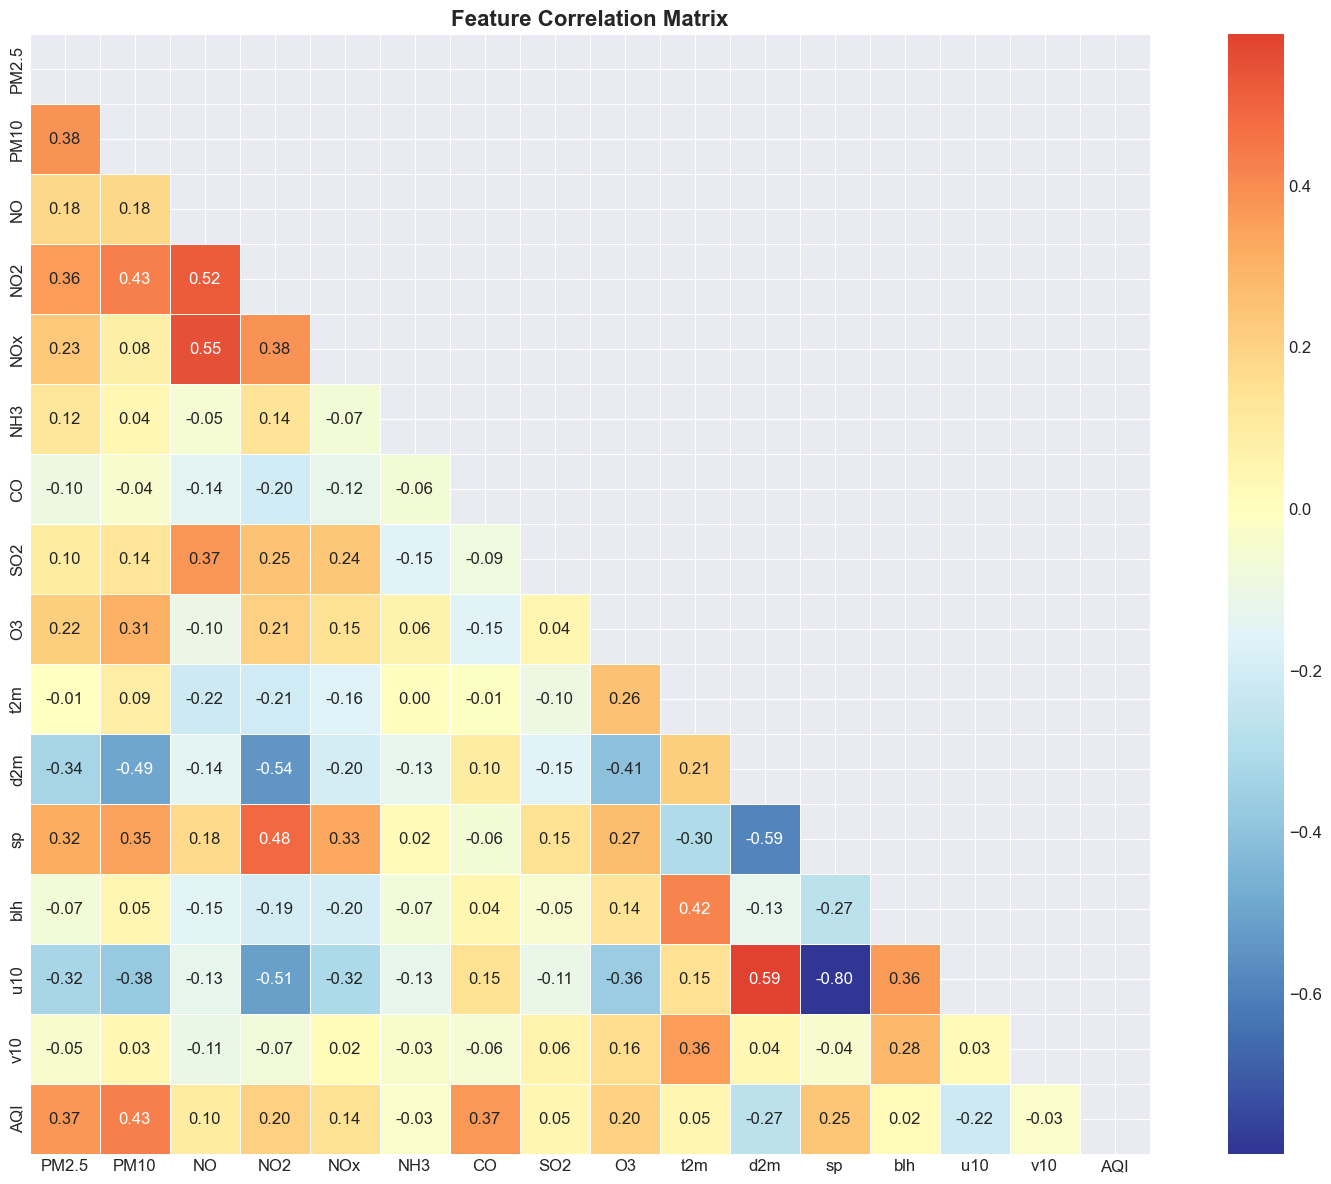

In [16]:
# 3f. Correlation heatmap
fig, ax = plt.subplots(figsize=(16, 12))
corr = df[POLLUTANTS + WEATHER + [TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

## 4. SARIMA Model
SARIMA(p,d,q)(P,D,Q,s) captures:
- **p, d, q** — Non-seasonal AR, differencing, MA orders
- **P, D, Q, s** — Seasonal AR, differencing, MA orders with period s
- For daily data with weekly seasonality: **s=7**

ADF Statistic: -4.1319
p-value      : 0.000858
Stationary?  : Yes


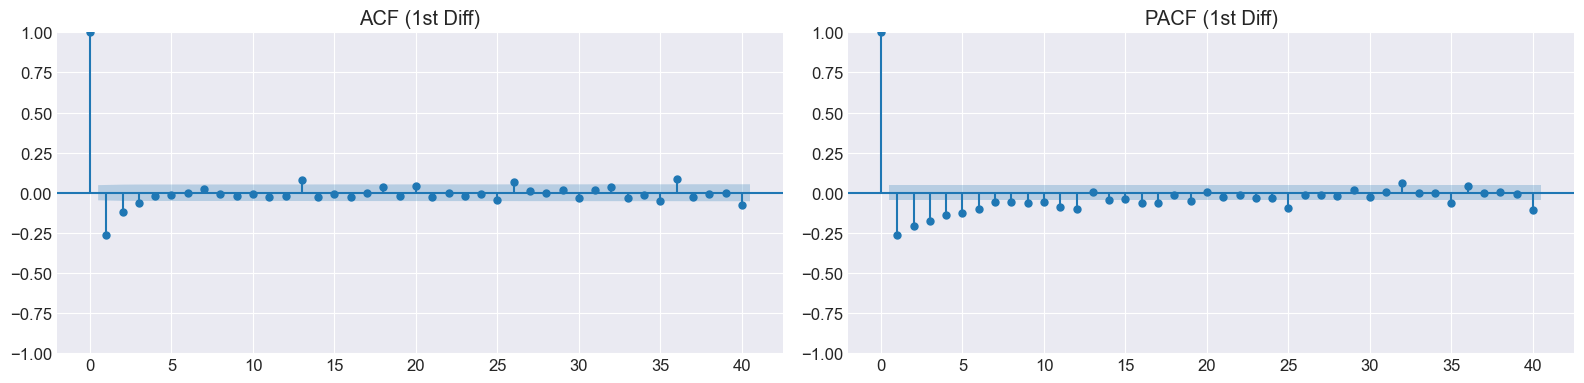

In [17]:
# Stationarity test on AQI
adf_result = adfuller(df[TARGET], autolag='AIC')
print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value      : {adf_result[1]:.6f}')
print(f'Stationary?  : {"Yes" if adf_result[1] < 0.05 else "No — differencing needed"}')

# ACF / PACF plots
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df[TARGET].diff().dropna(), lags=40, ax=axes[0], title='ACF (1st Diff)')
plot_pacf(df[TARGET].diff().dropna(), lags=40, ax=axes[1], title='PACF (1st Diff)')
plt.tight_layout(); plt.show()

In [18]:
# Train-test split (80-20 temporal split)
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]
print(f'Train: {len(train_df)} days ({train_df.index.min()} to {train_df.index.max()})')
print(f'Test : {len(test_df)} days ({test_df.index.min()} to {test_df.index.max()})')

Train: 1373 days (2015-04-20 00:00:00 to 2019-01-21 00:00:00)
Test : 344 days (2019-01-22 00:00:00 to 2019-12-31 00:00:00)


In [19]:
# Fit SARIMA — order selection based on ACF/PACF + domain knowledge
# Using SARIMA(1,1,1)(1,1,1,7) as baseline for daily data with weekly seasonality
SARIMA_ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 1, 1, 7)

print(f'Fitting SARIMA{SARIMA_ORDER}x{SEASONAL_ORDER}... (this may take a minute)')
sarima_model = SARIMAX(
    train_df[TARGET],
    order=SARIMA_ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False, maxiter=200)
print(sarima_fit.summary().tables[0])
print(sarima_fit.summary().tables[1])

Fitting SARIMA(1, 1, 1)x(1, 1, 1, 7)... (this may take a minute)
                                     SARIMAX Results                                     
Dep. Variable:                               AQI   No. Observations:                 1373
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -6719.264
Date:                           Tue, 07 Apr 2026   AIC                          13448.528
Time:                                   00:44:04   BIC                          13474.589
Sample:                               04-20-2015   HQIC                         13458.285
                                    - 01-21-2019                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4855      0.018     26.623      0.000   

SARIMA Test Performance:
  MAE  = 38.66
  RMSE = 44.61
  MAPE = 53.90%


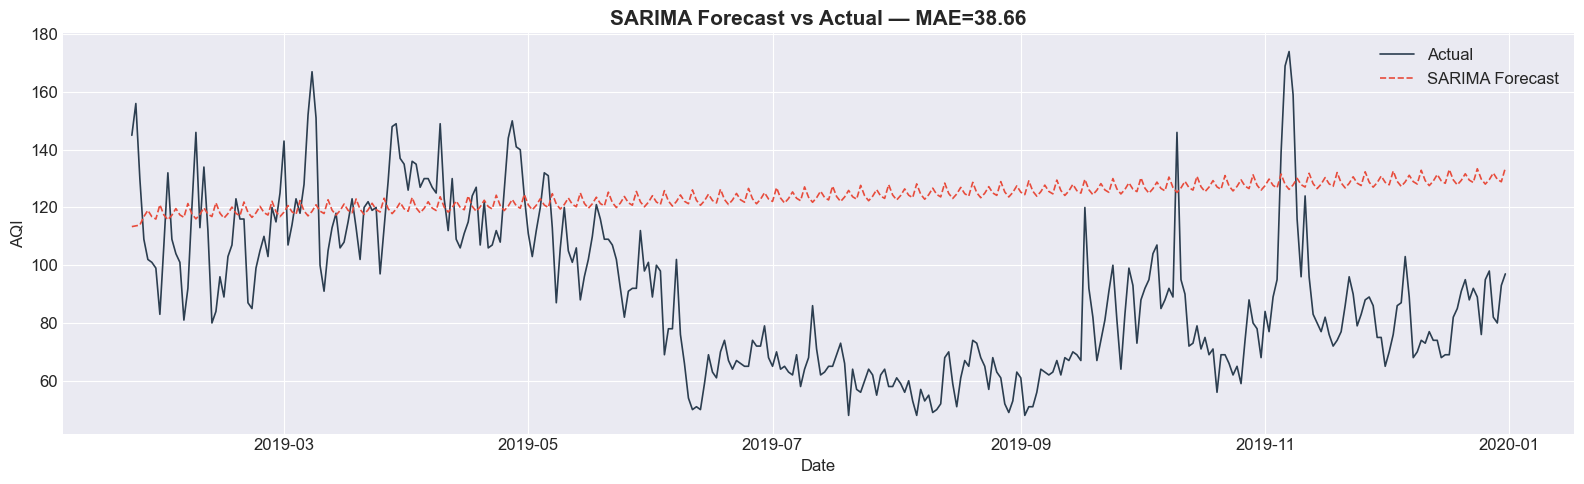

In [20]:
# SARIMA predictions on test set
sarima_pred_test = sarima_fit.forecast(steps=len(test_df))
sarima_pred_test.index = test_df.index

# SARIMA in-sample fitted values for train set
sarima_pred_train = sarima_fit.fittedvalues

# Evaluate SARIMA
sarima_mae  = mean_absolute_error(test_df[TARGET], sarima_pred_test)
sarima_rmse = np.sqrt(mean_squared_error(test_df[TARGET], sarima_pred_test))
sarima_mape = np.mean(np.abs((test_df[TARGET] - sarima_pred_test) / test_df[TARGET])) * 100

print(f'SARIMA Test Performance:')
print(f'  MAE  = {sarima_mae:.2f}')
print(f'  RMSE = {sarima_rmse:.2f}')
print(f'  MAPE = {sarima_mape:.2f}%')

# Plot
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_df.index, test_df[TARGET], label='Actual', color='#2c3e50', linewidth=1.2)
ax.plot(test_df.index, sarima_pred_test, label='SARIMA Forecast', color='#e74c3c', linewidth=1.2, linestyle='--')
ax.set_title(f'SARIMA Forecast vs Actual — MAE={sarima_mae:.2f}', fontsize=15, fontweight='bold')
ax.legend(); ax.set_xlabel('Date'); ax.set_ylabel('AQI')
plt.tight_layout(); plt.show()

## 5. Hybrid Integration — Feature Fusion
**Key idea:** Add SARIMA's predicted AQI as an additional feature for XGBoost.

```
Final Features = [Pollutants + Weather + Lag Features + Rolling Stats + Time Features + SARIMA_Prediction]
```

In [21]:
# Add SARIMA predictions as a feature to the full dataset
# For train: use in-sample fitted values; For test: use out-of-sample forecasts
df['SARIMA_pred'] = np.nan
df.loc[train_df.index, 'SARIMA_pred'] = sarima_pred_train
df.loc[test_df.index, 'SARIMA_pred']  = sarima_pred_test.values
df['SARIMA_pred'] = df['SARIMA_pred'].bfill().ffill()

# Define final feature set
FEATURE_COLS = [c for c in df.columns if c not in [TARGET, 'AQI_Bucket', 'city']]
print(f'Total features for XGBoost: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Total features for XGBoost: 28
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 't2m', 'd2m', 'sp', 'blh', 'u10', 'v10', 'AQI_lag_1', 'AQI_lag_2', 'AQI_lag_3', 'AQI_lag_7', 'AQI_lag_14', 'AQI_roll_7_mean', 'AQI_roll_7_std', 'AQI_roll_30_mean', 'day_of_week', 'month', 'day_of_year', 'is_weekend', 'SARIMA_pred']


In [22]:
# 5b. Normalize features using MinMaxScaler
scaler = MinMaxScaler()

X = df[FEATURE_COLS].copy()
y = df[TARGET].copy()

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

# Fit scaler on train only
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_COLS, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=FEATURE_COLS, index=X_test.index)

print(f'X_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}')

X_train: (1373, 28), X_test: (344, 28)


## 6. XGBoost Model
**Why XGBoost?**
- Captures complex nonlinear interactions between pollutants, weather & AQI
- Handles heterogeneous features (continuous + categorical)
- Built-in regularization prevents overfitting
- Gradient-boosted trees ensemble for robust predictions

In [23]:
# 6a. XGBoost WITHOUT SARIMA feature (standalone baseline)
xgb_only_features = [c for c in FEATURE_COLS if c != 'SARIMA_pred']

xgb_only_model = xgb.XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_SEED, n_jobs=-1
)
xgb_only_model.fit(
    X_train_scaled[xgb_only_features], y_train,
    eval_set=[(X_test_scaled[xgb_only_features], y_test)],
    verbose=False
)
xgb_only_pred = xgb_only_model.predict(X_test_scaled[xgb_only_features])

xgb_only_mae  = mean_absolute_error(y_test, xgb_only_pred)
xgb_only_rmse = np.sqrt(mean_squared_error(y_test, xgb_only_pred))
xgb_only_mape = np.mean(np.abs((y_test - xgb_only_pred) / y_test)) * 100

print(f'XGBoost (Standalone) Test Performance:')
print(f'  MAE  = {xgb_only_mae:.2f}')
print(f'  RMSE = {xgb_only_rmse:.2f}')
print(f'  MAPE = {xgb_only_mape:.2f}%')

XGBoost (Standalone) Test Performance:
  MAE  = 6.37
  RMSE = 8.47
  MAPE = 7.18%


In [24]:
# 6b. Hybrid XGBoost WITH SARIMA feature
hybrid_model = xgb.XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_SEED, n_jobs=-1
)
hybrid_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)
hybrid_pred = hybrid_model.predict(X_test_scaled)

hybrid_mae  = mean_absolute_error(y_test, hybrid_pred)
hybrid_rmse = np.sqrt(mean_squared_error(y_test, hybrid_pred))
hybrid_mape = np.mean(np.abs((y_test - hybrid_pred) / y_test)) * 100

print(f'Hybrid (SARIMA+XGBoost) Test Performance:')
print(f'  MAE  = {hybrid_mae:.2f}')
print(f'  RMSE = {hybrid_rmse:.2f}')
print(f'  MAPE = {hybrid_mape:.2f}%')

Hybrid (SARIMA+XGBoost) Test Performance:
  MAE  = 7.47
  RMSE = 9.66
  MAPE = 9.00%


## 7. Model Comparison & Evaluation

In [25]:
# Comparison table
results = pd.DataFrame({
    'Model': ['SARIMA', 'XGBoost (Standalone)', 'Hybrid (SARIMA+XGBoost)'],
    'MAE':  [sarima_mae, xgb_only_mae, hybrid_mae],
    'RMSE': [sarima_rmse, xgb_only_rmse, hybrid_rmse],
    'MAPE (%)': [sarima_mape, xgb_only_mape, hybrid_mape]
}).set_index('Model')

print('MODEL COMPARISON — TEST SET')
display(results.style.highlight_min(axis=0, color='#a8e6cf').format('{:.2f}'))

MODEL COMPARISON — TEST SET


,MAE,RMSE,MAPE (%)
Model,,,
SARIMA,38.66,44.61,53.90
XGBoost (Standalone),6.37,8.47,7.18
Hybrid (SARIMA+XGBoost),7.47,9.66,9.00


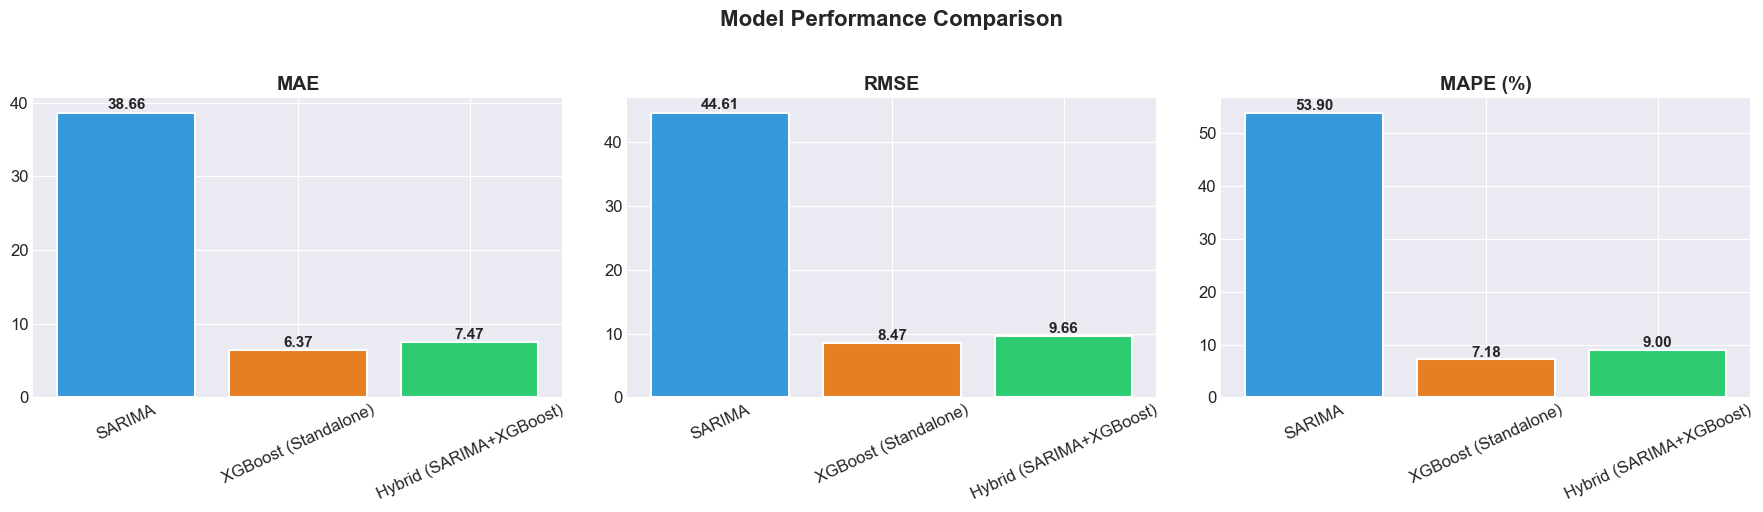

In [26]:
# Comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#3498db', '#e67e22', '#2ecc71']
metrics = ['MAE', 'RMSE', 'MAPE (%)']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(results.index, results[metric], color=colors, edgecolor='white', linewidth=1.5)
    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=25)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                     f'{bar.get_height():.2f}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

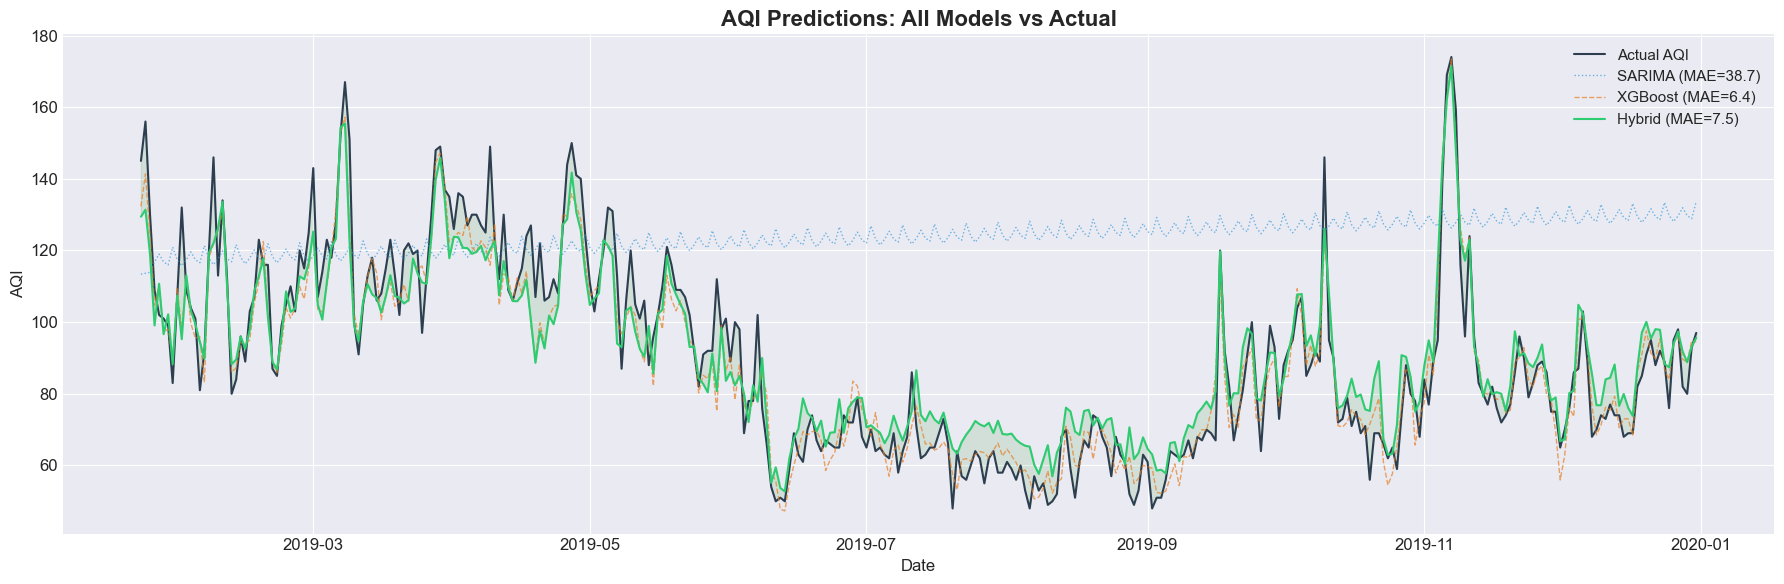

In [27]:
# Predictions overlay plot
fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(test_df.index, y_test, label='Actual AQI', color='#2c3e50', linewidth=1.5)
ax.plot(test_df.index, sarima_pred_test, label=f'SARIMA (MAE={sarima_mae:.1f})', color='#3498db', linewidth=1, alpha=0.7, linestyle=':')
ax.plot(test_df.index, xgb_only_pred, label=f'XGBoost (MAE={xgb_only_mae:.1f})', color='#e67e22', linewidth=1, alpha=0.7, linestyle='--')
ax.plot(test_df.index, hybrid_pred, label=f'Hybrid (MAE={hybrid_mae:.1f})', color='#2ecc71', linewidth=1.5)
ax.set_title('AQI Predictions: All Models vs Actual', fontsize=16, fontweight='bold')
ax.legend(fontsize=11); ax.set_xlabel('Date'); ax.set_ylabel('AQI')
ax.fill_between(test_df.index, y_test, hybrid_pred, alpha=0.1, color='green')
plt.tight_layout(); plt.show()

## 8. Explainable AI — SHAP Analysis
**SHAP (SHapley Additive exPlanations):**
- Based on cooperative game theory (Shapley values)
- Each feature gets a fair contribution score for every prediction
- **Global explanation:** Overall feature importance across all predictions
- **Local explanation:** Why a specific prediction was made

In [28]:
# 8a. Compute SHAP values for the Hybrid model
explainer = shap.TreeExplainer(hybrid_model)
shap_values = explainer.shap_values(X_test_scaled)
print(f'SHAP values shape: {shap_values.shape}')
print(f'Features: {X_test_scaled.shape[1]}, Test samples: {X_test_scaled.shape[0]}')

SHAP values shape: (344, 28)
Features: 28, Test samples: 344


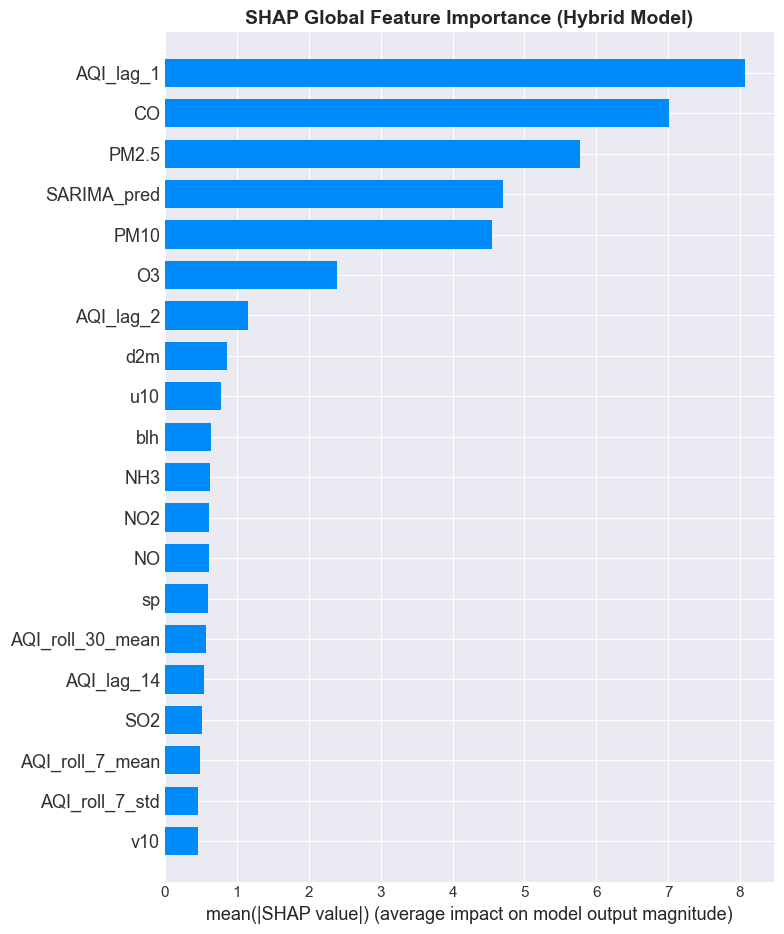

In [29]:
# 8b. SHAP Summary Plot — Global Feature Importance
# Shows which features have the biggest impact on predictions
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_scaled, plot_type='bar', show=False)
plt.title('SHAP Global Feature Importance (Hybrid Model)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

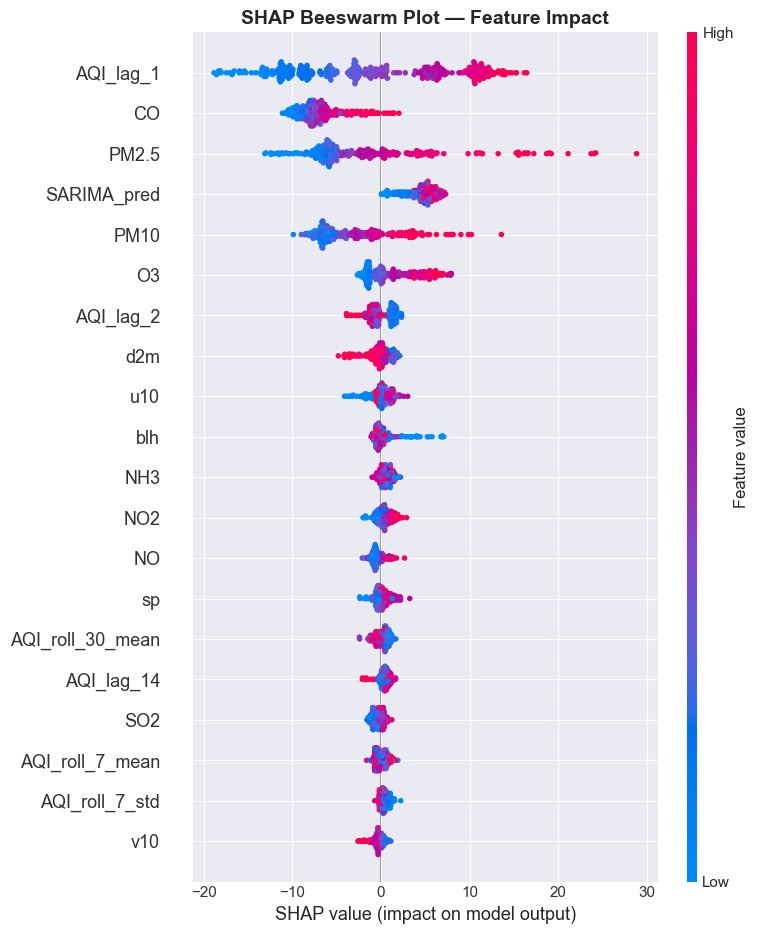

In [30]:
# 8c. SHAP Beeswarm Plot — Feature Impact Direction
# Shows how feature values (high/low) affect predictions
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.title('SHAP Beeswarm Plot — Feature Impact', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

Sample Date  : 2019-01-22 00:00:00
Actual AQI   : 145.0
Predicted AQI: 129.4
Base Value   : 96.8

Top feature contributions for this prediction:


,Feature,SHAP Value
0,PM2.5,18.677563
1,PM10,7.959218
15,AQI_lag_1,5.950062
8,O3,3.696513
6,CO,-3.340131
10,d2m,1.821741
3,NO2,1.517405
9,t2m,-1.158128
16,AQI_lag_2,-1.040019
7,SO2,-0.958036


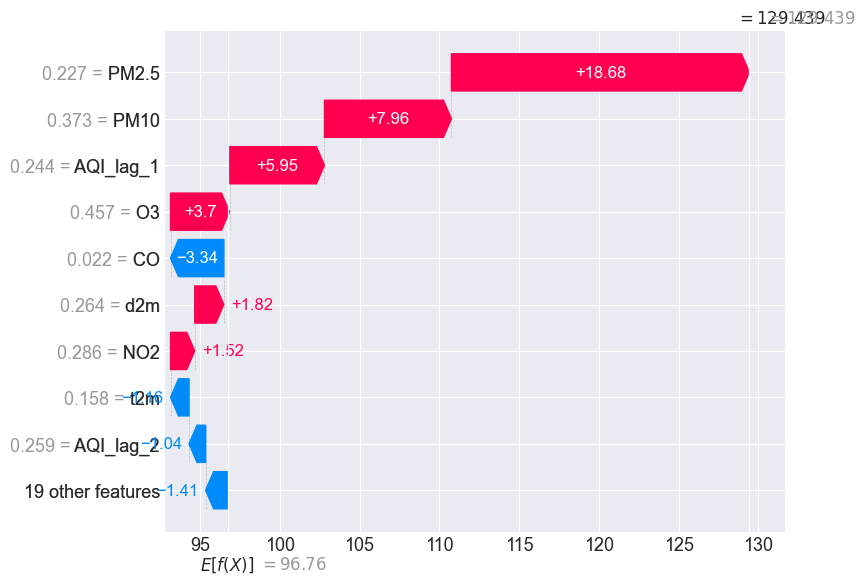

In [31]:
# 8d. SHAP Force Plot — Local Explanation (Single Prediction)
# Explain why a specific test sample got its predicted AQI value
sample_idx = 0  # First test sample
print(f'Sample Date  : {X_test_scaled.index[sample_idx]}')
print(f'Actual AQI   : {y_test.iloc[sample_idx]:.1f}')
print(f'Predicted AQI: {hybrid_pred[sample_idx]:.1f}')
print(f'Base Value   : {explainer.expected_value:.1f}\n')

# Force plot (text-based breakdown)
sv = shap_values[sample_idx]
feat_contrib = pd.DataFrame({'Feature': FEATURE_COLS, 'SHAP Value': sv})
feat_contrib = feat_contrib.reindex(feat_contrib['SHAP Value'].abs().sort_values(ascending=False).index)
print('Top feature contributions for this prediction:')
display(feat_contrib.head(10))

# Waterfall plot for single prediction
shap.plots.waterfall(shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_scaled.iloc[sample_idx],
    feature_names=FEATURE_COLS
), show=True)

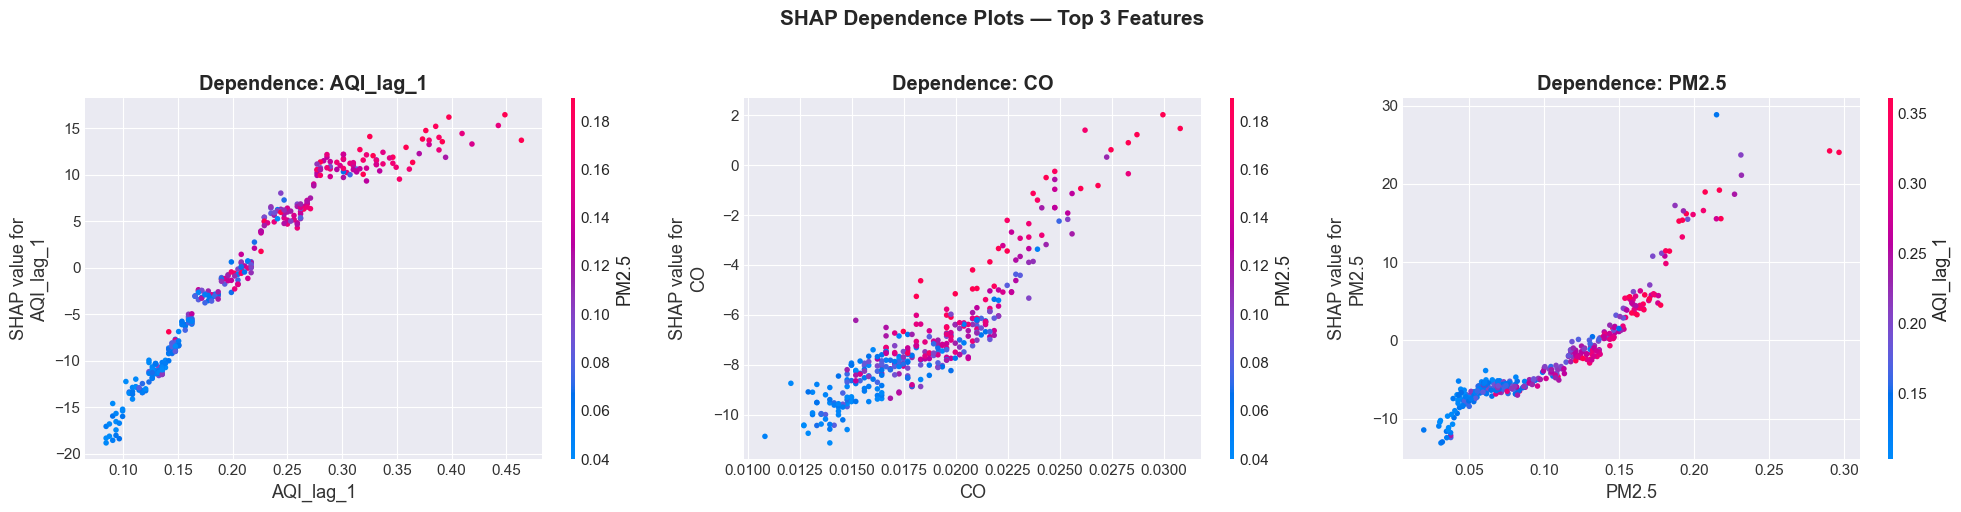

In [32]:
# 8e. SHAP Dependence Plot — How top features affect AQI
# Get top 3 most important features
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features = np.array(FEATURE_COLS)[np.argsort(-mean_abs_shap)[:3]]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, feat in enumerate(top_features):
    shap.dependence_plot(feat, shap_values, X_test_scaled, ax=axes[i], show=False)
    axes[i].set_title(f'Dependence: {feat}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots — Top 3 Features', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 9. XGBoost Native Feature Importance

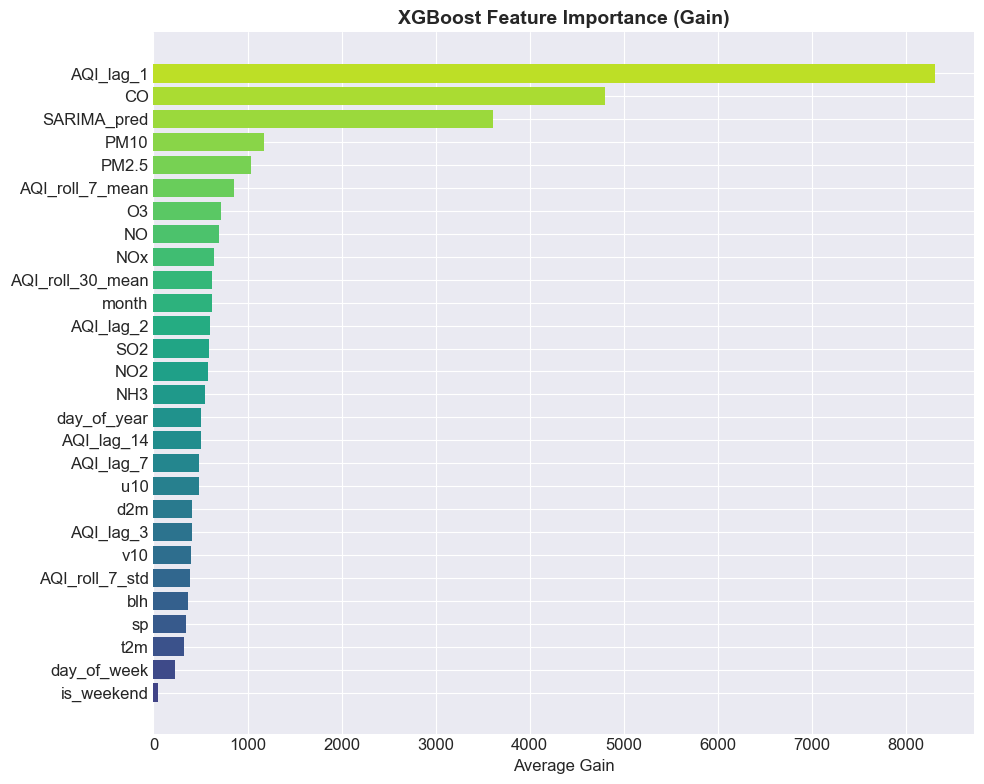

In [33]:
# XGBoost built-in feature importance (gain-based)
importance = hybrid_model.get_booster().get_score(importance_type='gain')
imp_df = pd.DataFrame({'Feature': list(importance.keys()), 'Gain': list(importance.values())})
imp_df = imp_df.sort_values('Gain', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(imp_df['Feature'], imp_df['Gain'], color=plt.cm.viridis(np.linspace(0.2, 0.9, len(imp_df))))
ax.set_title('XGBoost Feature Importance (Gain)', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Gain')
plt.tight_layout(); plt.show()

## 10. Final Output & Architecture Summary

In [34]:
# Final architecture diagram (text-based)
arch = """
=========================== HYBRID AQI PREDICTION — SYSTEM ARCHITECTURE ===========================

  [Raw Data] --> [Preprocessing] --> [SARIMA] ------->\\
       (CSV)      - Missing values     (1,1,1)         \\
                  - Normalization       (1,1,1,7)        --> [FEATURE FUSION] --> [XGBoost] --> [SHAP] --> [OUTPUT]
                  - Lag features                        /    Pollutants+Weather   Gradient     Global &    Predicted AQI
                  - Rolling stats   ------------------>/     +Lags+Rolling        Boosted      Local       + Feature
                  - Time features                            +Time+SARIMA_pred    Trees        Explanations  Explanations

===================================================================================================
"""
print(arch)


=========================== HYBRID AQI PREDICTION — SYSTEM ARCHITECTURE ===========================

  [Raw Data] --> [Preprocessing] --> [SARIMA] ------->\
       (CSV)      - Missing values     (1,1,1)         \
                  - Normalization       (1,1,1,7)        --> [FEATURE FUSION] --> [XGBoost] --> [SHAP] --> [OUTPUT]
                  - Lag features                        /    Pollutants+Weather   Gradient     Global &    Predicted AQI
                  - Rolling stats   ------------------>/     +Lags+Rolling        Boosted      Local       + Feature
                  - Time features                            +Time+SARIMA_pred    Trees        Explanations  Explanations




In [35]:
# Final prediction demonstration
print('=' * 60)
print('  FINAL HYBRID MODEL — SAMPLE PREDICTIONS')
print('=' * 60)

sample_results = pd.DataFrame({
    'Date': test_df.index[:10],
    'Actual_AQI': y_test.values[:10],
    'SARIMA_Pred': sarima_pred_test.values[:10],
    'XGBoost_Pred': xgb_only_pred[:10],
    'Hybrid_Pred': hybrid_pred[:10]
}).round(1)

sample_results['Hybrid_Error'] = (sample_results['Actual_AQI'] - sample_results['Hybrid_Pred']).abs().round(1)
display(sample_results)

print(f'\nBest Model: Hybrid (SARIMA + XGBoost)')
print(f'   MAE  = {hybrid_mae:.2f}')
print(f'   RMSE = {hybrid_rmse:.2f}')
print(f'   MAPE = {hybrid_mape:.2f}%')
print(f'\nSHAP provides transparent, feature-level explanations for every prediction.')

  FINAL HYBRID MODEL — SAMPLE PREDICTIONS


,Date,Actual_AQI,SARIMA_Pred,XGBoost_Pred,Hybrid_Pred,Hybrid_Error
0,2019-01-22,145.0,113.4,132.300003,129.399994,15.6
1,2019-01-23,156.0,113.7,141.399994,131.399994,24.6
2,2019-01-24,130.0,113.9,124.199997,119.000000,11.0
3,2019-01-25,109.0,116.8,104.699997,99.099998,9.9
4,2019-01-26,102.0,119.0,110.300003,110.699997,8.7
5,2019-01-27,101.0,116.8,97.099998,96.599998,4.4
6,2019-01-28,99.0,116.0,98.099998,102.199997,3.2
7,2019-01-29,83.0,120.9,89.300003,88.300003,5.3
8,2019-01-30,107.0,117.4,109.300003,107.400002,0.4
9,2019-01-31,132.0,115.7,98.000000,95.199997,36.8



Best Model: Hybrid (SARIMA + XGBoost)
   MAE  = 7.47
   RMSE = 9.66
   MAPE = 9.00%

SHAP provides transparent, feature-level explanations for every prediction.


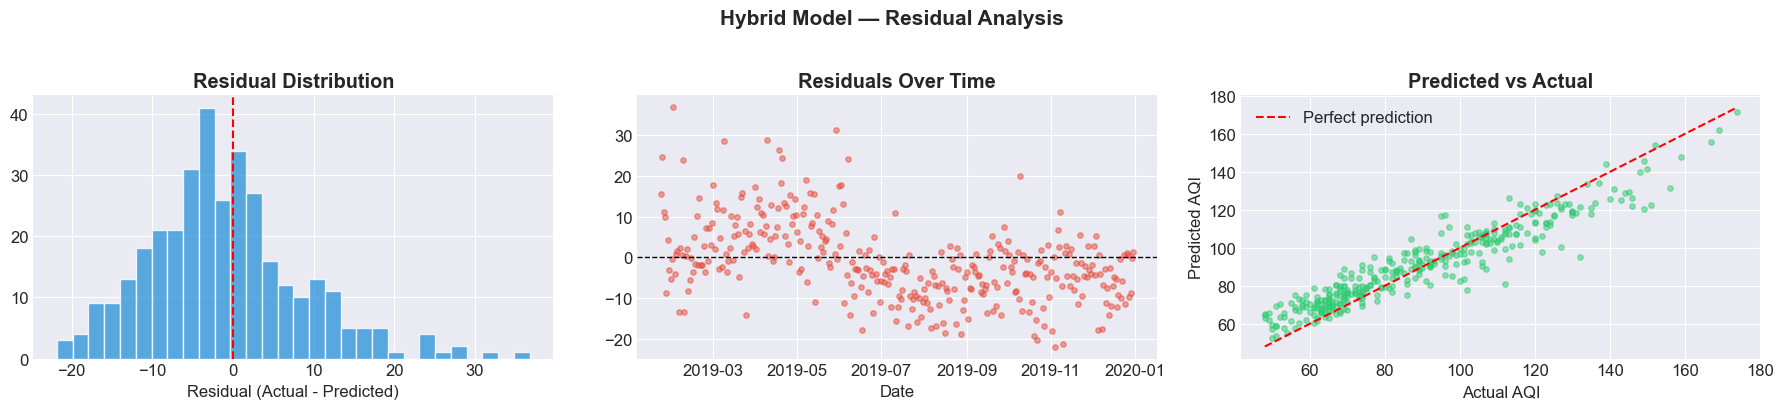

In [36]:
# Residual analysis for the hybrid model
residuals = y_test.values - hybrid_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Residual distribution
axes[0].hist(residuals, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residual Distribution', fontweight='bold')
axes[0].set_xlabel('Residual (Actual - Predicted)')

# Residuals over time
axes[1].scatter(test_df.index, residuals, alpha=0.5, s=15, color='#e74c3c')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Residuals Over Time', fontweight='bold')
axes[1].set_xlabel('Date')

# Predicted vs Actual scatter
axes[2].scatter(y_test, hybrid_pred, alpha=0.5, s=15, color='#2ecc71')
lims = [min(y_test.min(), hybrid_pred.min()), max(y_test.max(), hybrid_pred.max())]
axes[2].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[2].set_title('Predicted vs Actual', fontweight='bold')
axes[2].set_xlabel('Actual AQI'); axes[2].set_ylabel('Predicted AQI')
axes[2].legend()

plt.suptitle('Hybrid Model — Residual Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()